<div align="center">

## Gini PCA: Application on Cars Data

## [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage")

</div>


<div align="center"> <a href="https://www.python.org/"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/Python_logo_and_wordmark.svg/390px-Python_logo_and_wordmark.svg.png" style="max-width: 150px; display: inline" alt="Python"/></a> 
</div>

<div align="center"> 
<a href="http://scikit-learn.org/stable/#"><img src="http://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" style="max-width: 180px; display: inline" alt="Scikit-Learn"/></a>
</div>

In [1]:
#pip install torch
#pip install torchvision

In [2]:
from Gini_PCA import GiniPca

# Other packages
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    from OUTLIERS import smirnov_grubbs as grubbs
except ImportError:
    from outliers import smirnov_grubbs as grubbs

###  <span style="color:red">Dataset importation</span>

In [3]:
cars = pd.read_excel("cars.xlsx",index_col=0)
cars.head()
model = GiniPca(gini_param=2, n_components=3)
x = torch.DoubleTensor(cars.values)


In [4]:
model.ranks(x)

tensor([[ 10.5000,  10.5000,   7.5000,  10.5000,  10.5000,   9.5000],
        [ 11.5000,  11.5000,  11.0000,  11.5000,  11.5000,  11.5000],
        [  6.5000,   0.0000,   0.5000,   6.5000,   8.5000,  10.5000],
        [  9.5000,   9.5000,   9.5000,   9.5000,   9.5000,   8.5000],
        [ -5.0000,  -6.5000,  -6.0000,   1.5000,  -2.5000,   7.5000],
        [  3.0000,   7.0000,   2.5000,   3.5000,   3.0000,   1.5000],
        [  8.5000,   8.5000,   6.5000,   7.5000,   5.5000,   2.5000],
        [ -5.0000,  -4.5000,  -1.5000,  -4.5000,  -3.5000,  -4.5000],
        [ -2.5000,   0.0000,  -3.0000,  -3.5000,   6.5000,  -2.5000],
        [ -6.5000,  -5.5000,  -6.0000,  -2.5000,  -5.5000,  -8.5000],
        [ -3.5000,  -3.5000,  -3.0000,  -6.5000,  -4.5000,  -9.5000],
        [ -8.5000,  -8.5000,  -8.0000,  -8.5000,  -6.5000, -10.5000],
        [ -7.5000,  -7.5000,  -8.0000,  -9.5000,  -9.5000, -11.5000],
        [  7.5000,   5.5000,   3.5000,   8.5000,   7.5000,   5.5000],
        [  0.5000,  

In [5]:
model.gmd(x)

tensor([[1635.5978, 1577.1449, 1476.1304, 1201.6196, 1445.8152, 1196.6920],
        [ 151.3478,  158.4130,  152.8188,   88.8043,  130.6123,   98.3623],
        [  54.0725,   60.5145,   63.8225,   28.7862,   43.4130,   37.1558],
        [ 359.0254,  304.0217,  224.4601,  442.6377,  367.3370,  362.0507],
        [ 173.2826,  162.8080,  136.0870,  117.6739,  207.1232,  153.9565],
        [ 530.1014,  465.5399,  434.7319,  545.7101,  545.1449,  640.5217]],
       dtype=torch.float64)

In [6]:
model.scale_gini(x)

tensor([[-9.7734e-01, -9.1954e-01, -8.8853e-01, -1.2529e+00, -8.6623e-01,
         -9.5521e-01],
        [-1.2378e+00, -9.7635e-01, -1.2489e+00, -1.7093e+00, -1.5615e+00,
         -2.7756e+00],
        [-6.8754e-01, -2.3146e-01,  5.1575e-02, -6.1356e-01, -7.1656e-01,
         -1.0192e+00],
        [-9.0642e-01, -8.9429e-01, -9.5121e-01, -1.1784e+00, -8.6140e-01,
         -8.7871e-01],
        [ 1.3662e-01,  3.0511e-01,  4.7462e-01, -1.9561e-01, -1.3720e-01,
         -7.2727e-01],
        [-5.0535e-01, -6.4178e-01, -4.3415e-01, -4.3282e-01, -3.5446e-01,
         -1.1683e-01],
        [-8.0982e-01, -8.6272e-01, -8.5720e-01, -6.9489e-01, -4.4619e-01,
         -1.1839e-01],
        [ 1.3662e-01,  2.7355e-02,  2.2393e-01,  3.4660e-01, -1.3237e-01,
          6.2163e-01],
        [-2.2953e-02, -2.3146e-01,  2.3960e-01,  2.5623e-01, -5.3310e-01,
          3.9057e-01],
        [ 1.6536e-01,  7.1543e-02,  4.7462e-01,  2.4493e-01,  3.6613e-02,
          8.7923e-01],
        [-1.5540e-03,  2.1042e

In [7]:
z = model.scale_gini(x) # standardization of x
print ("Gini correlation :" , "\n", model.gmd(z))


Gini correlation : 
 tensor([[1.0000, 0.9643, 0.9025, 0.7347, 0.8840, 0.7317],
        [0.9554, 1.0000, 0.9647, 0.5606, 0.8245, 0.6209],
        [0.8472, 0.9482, 1.0000, 0.4510, 0.6802, 0.5822],
        [0.8111, 0.6868, 0.5071, 1.0000, 0.8299, 0.8179],
        [0.8366, 0.7860, 0.6570, 0.5681, 1.0000, 0.7433],
        [0.8276, 0.7268, 0.6787, 0.8520, 0.8511, 1.0000]], dtype=torch.float64)


In [8]:
print ("Gini correlations :" , "\n", model.gini_correl(x))

Gini correlations : 
 tensor([[1.0000, 0.9643, 0.9025, 0.7347, 0.8840, 0.7317],
        [0.9554, 1.0000, 0.9647, 0.5606, 0.8245, 0.6209],
        [0.8472, 0.9482, 1.0000, 0.4510, 0.6802, 0.5822],
        [0.8111, 0.6868, 0.5071, 1.0000, 0.8299, 0.8179],
        [0.8366, 0.7860, 0.6570, 0.5681, 1.0000, 0.7433],
        [0.8276, 0.7268, 0.6787, 0.8520, 0.8511, 1.0000]], dtype=torch.float64)


In [9]:
print ("Pearson correlations", "\n", torch.corrcoef(x.T))

Pearson correlations 
 tensor([[1.0000, 0.9540, 0.8854, 0.6922, 0.7061, 0.6639],
        [0.9540, 1.0000, 0.9338, 0.5288, 0.7300, 0.5268],
        [0.8854, 0.9338, 1.0000, 0.4663, 0.6188, 0.5781],
        [0.6922, 0.5288, 0.4663, 1.0000, 0.4772, 0.7948],
        [0.7061, 0.7300, 0.6188, 0.4772, 1.0000, 0.5913],
        [0.6639, 0.5268, 0.5781, 0.7948, 0.5913, 1.0000]], dtype=torch.float64)


###  <span style="color:red">Descriptive Statistics</span>


In [10]:
cars.mean()

Cylinder    2722.541667
Power        206.666667
Speed        214.708333
Weight      1486.583333
Width       1838.416667
Length      4277.833333
dtype: float64

In [11]:
cars.std()

Cylinder    1516.444583
Power        155.721230
Speed         56.571985
Weight       387.506625
Width        220.841851
Length       581.496620
dtype: float64

In [12]:
cars.columns

Index(['Cylinder', 'Power', 'Speed', 'Weight', 'Width', 'Length'], dtype='object')

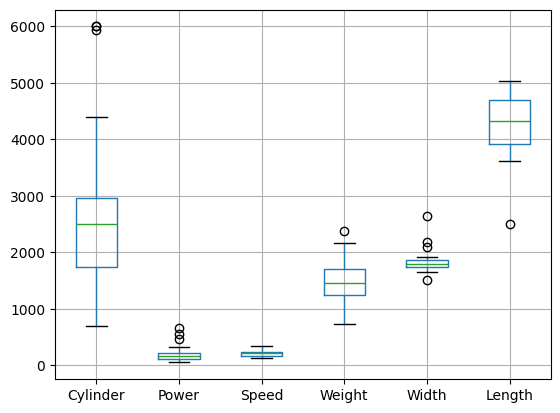

In [13]:
boxplot = cars.boxplot(column=['Cylinder', 'Power', 'Speed', 'Weight', 'Width', 'Length'])

In [14]:
model.optimal_gini_param(x)

tensor(2.4000)

In [15]:
model = GiniPca(gini_param = 2.4, n_components = 3)
model.eigen_val(x)

tensor([ 8.1317e+01,  1.1662e+01,  3.7602e+00,  2.9675e+00,  2.9744e-01,
        -4.2498e-03], dtype=torch.float64)

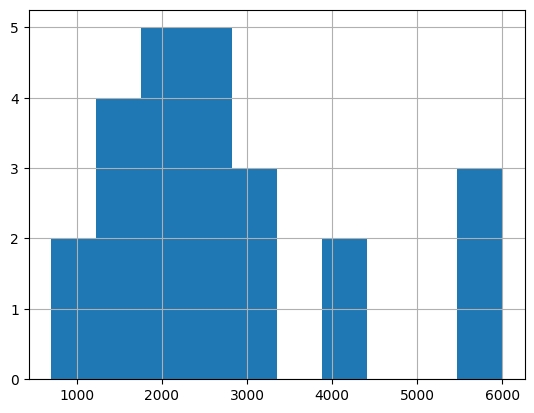

In [16]:
cars["Cylinder"].hist(bins=10)
plt.show()

###  <span style="color:red">Principal Components </span>

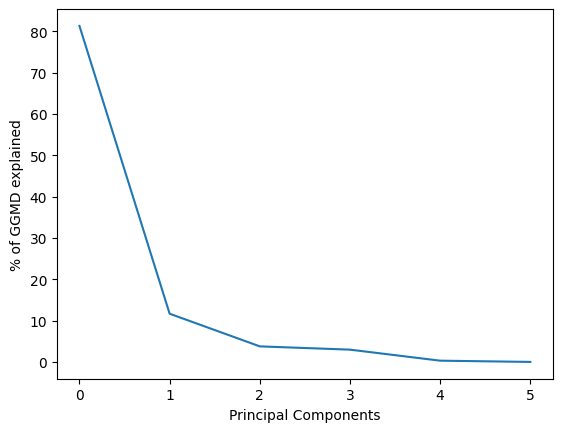

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

# Graph: % of GGMD of each principal component
plt.plot(model.eigen_val(x))
plt.xlabel("Principal Components")
plt.ylabel("% of GGMD explained")
plt.show()

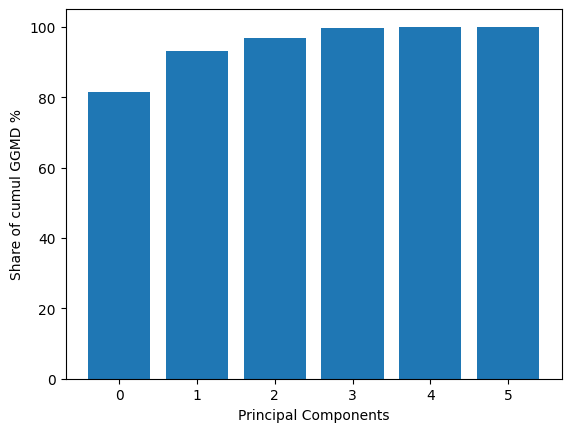

In [18]:
### % Cumul GGMD

valp_ratios = torch.cumsum(model.eigen_val(x), dim = 0)
plt.bar(range(len(valp_ratios)), valp_ratios)
plt.xticks(range(len(valp_ratios)))
plt.xlabel("Principal Components")
plt.ylabel("Share of cumul GGMD %")
plt.show()


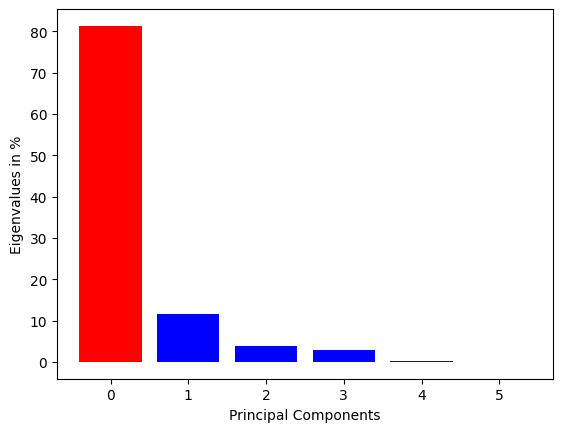

In [19]:
### % Cumul GGMD

valp_ratios = model.eigen_val(x)
color = []
for value in valp_ratios:
    if value > 70:
        color.append('red')
    else:
        color.append('blue')
plt.bar(range(len(valp_ratios)), valp_ratios, color = color)
plt.xticks(range(len(valp_ratios)))
plt.xlabel("Principal Components")
plt.ylabel("Eigenvalues in %")
plt.show()


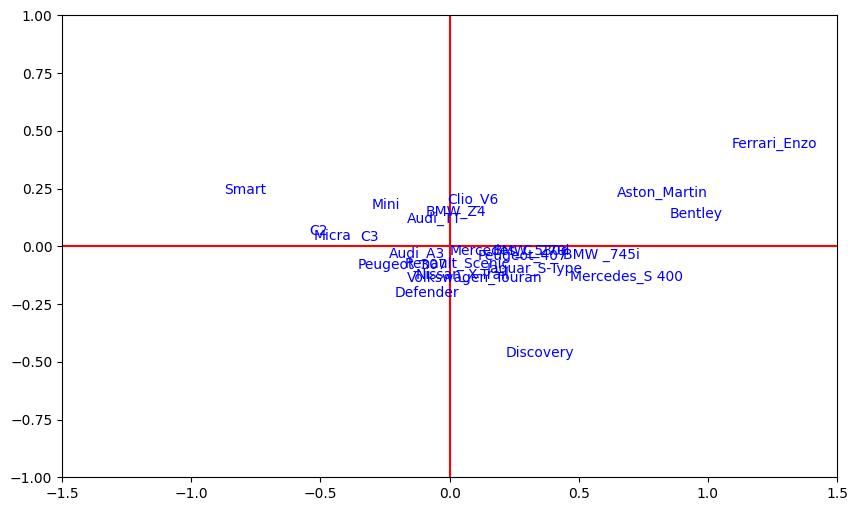

In [20]:
# Projection of the points (Gini)
components = model.fit(x)[0] 
plt.figure(figsize=(10,6))
for i, j, label in zip(components[:,0], components[:,1], cars.index):
    plt.text(i, j, label, color="blue")
plt.axis((-1.5,1.5,-1,1))  
plt.axhline(0, color='red')  # horizontal axis
plt.axvline(0, color='red')  # vertical axis
plt.show()

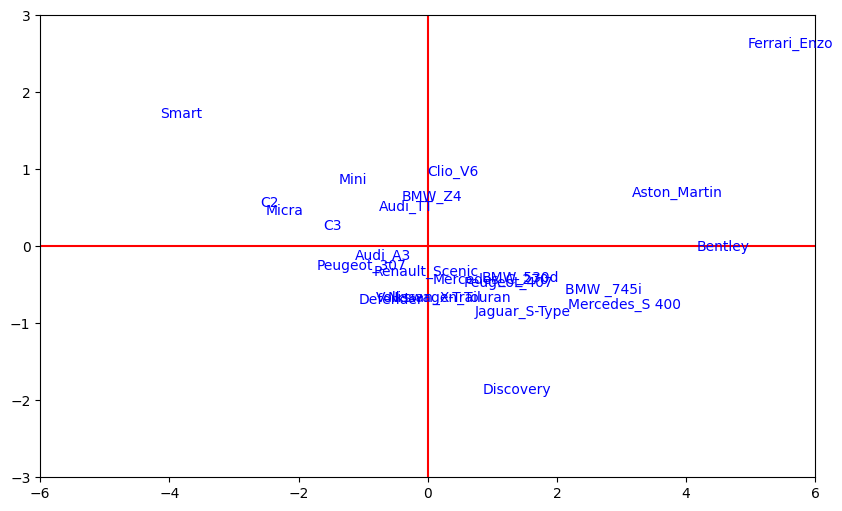

In [21]:
# Projection of the points (Variance)
cars_scale=scale(cars) # standardization
pca = PCA()
comp_var = pca.fit_transform(cars_scale)
# Plot
plt.figure(figsize=(10,6))
for i, j, label in zip(comp_var[:,0], comp_var[:,1], cars.index):
    plt.text(i, j, label, color="blue")
plt.axis((-6,6,-3,3)) 
plt.axhline(0, color='red')  # horizontal axis
plt.axvline(0, color='red')  # vertical axis
plt.show()

In [22]:
# Grubbs test 10%
components_copy = components.numpy()
outliers_var = []
outliers_gini = []
for i in range (2):
    outliers_var.append(grubbs.max_test_indices(comp_var[:,i], alpha = 0.1))
    outliers_gini.append(grubbs.max_test_indices(components_copy[:,i], alpha = 0.1))
print('Atypical points in standard PCA:', outliers_var)
print('Atypical points in Gini PCA:', outliers_gini)

Atypical points in standard PCA: [[], [18]]
Atypical points in Gini PCA: [[], []]


In [23]:
# Grubbs test (10%)
model.outliers(x)

5

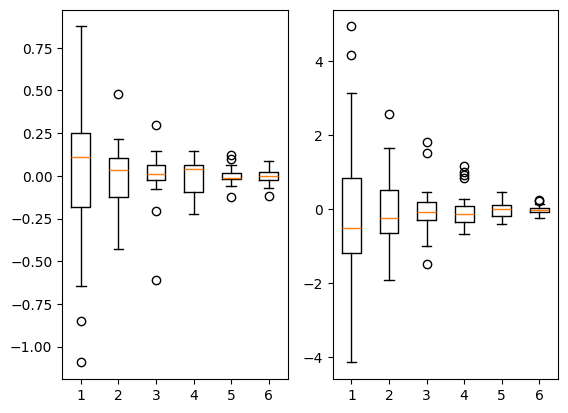

In [24]:
### Box plot
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.boxplot(components_copy*(-1))
ax2.boxplot(comp_var)
plt.show()



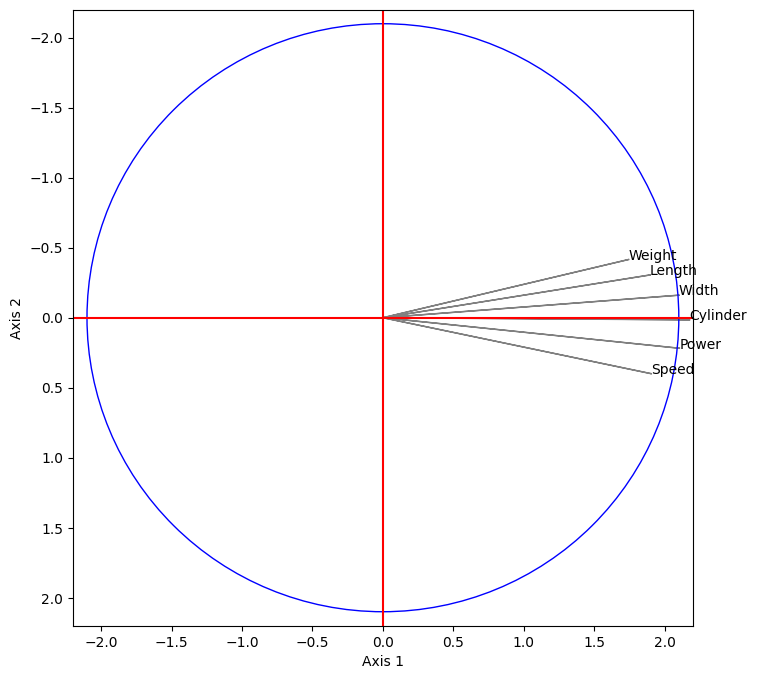

In [25]:
# Circle of correlations
project_var = model.gini_correl_axis(x)
# Plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1)
for i, j, label in zip(project_var[0,:],project_var[1,:], cars.columns):
    plt.text(i, j, label)
    plt.arrow(0,0,i,j,color='gray')
plt.axis((-2.2,2.2,2.2,-2.2))
# Circle
circle = plt.Circle((0,0), radius=2.1, color='blue', fill=False)
ax.add_patch(circle)
plt.axvline(0, color='r') # vertical axis
plt.axhline(0, color='r') # horizontal axis
plt.xlabel("Axis 1")
plt.ylabel("Axis 2")
plt.show()


### ACT of variables 


In [26]:
# Absolute contributions Axis 1: ACT of features
U = model.u_stat(x)
U_test = []
for i,value in enumerate(U[0,:]):
    if torch.abs(value) >= 1.96:
        U_test.append(cars.columns[i])
print("Significant variables on axis 1:", U_test)

Significant variables on axis 1: ['Cylinder', 'Power', 'Speed', 'Weight', 'Width', 'Length']


In [27]:
# Absolute contributions Axis 2: ACT of features
U = model.u_stat(x)
U_test = []
for i,value in enumerate(U[1,:]):
    if torch.abs(value) >= 1.96:
        U_test.append(cars.columns[i])
print("Significant variables on axis 1:", U_test)

Significant variables on axis 1: []


### ACT of points

In [28]:
# Axis 1: ACT of individuals
ACT = model.absolute_contrib(x)*100
list_1 = []
for i,value in enumerate(ACT[:,0]):
    if ACT[i,0] >= 4.17: 
        list_1.append(cars.index[i])
print("Significant individuals:", list_1)

Significant individuals: ['C2', 'Smart', 'Micra', 'BMW _745i', 'Mercedes_S 400', 'Aston_Martin', 'Bentley', 'Ferrari_Enzo']


In [29]:
# Axis 2: ACT of individuals
ACT = model.absolute_contrib(x)*100
liste_2 = []
for i,value in enumerate(ACT[:,1]):
    if ACT[i,1] >= 4.17: 
        liste_2.append(cars.index[i])
print("Significant individuals:", liste_2)

Significant individuals: ['Mini', 'Clio_V6', 'BMW_Z4', 'Ferrari_Enzo', 'Volkswagen_Touran', 'Defender', 'Discovery']


In [30]:
# Relative contributions RCT (axis 1)
RCT = model.relative_contrib(x)
print("Relative contributions:",'\n', RCT[:,0])

Relative contributions: 
 tensor([6.5880e-02, 1.0578e-01, 3.6347e-02, 6.3720e-02, 9.1976e-04, 2.8508e-02,
        4.3232e-02, 1.2996e-02, 5.0367e-05, 2.0212e-02, 1.7229e-02, 5.3200e-02,
        5.6301e-02, 4.1687e-02, 1.1111e-02, 1.9939e-02, 7.8235e-02, 1.0314e-01,
        1.3223e-01, 2.1061e-02, 2.0197e-02, 2.5857e-02, 2.6459e-02, 1.5709e-02],
       dtype=torch.float64)


### Plot 3D

c:\Users\smussa01\Documents\Python Scripts\Book Gini\ACP\Gini_PCA.py:168: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(F[line, 0], F[line, 1], F[line, 2], cmap=plt.cm.Set1, edgecolor='k', s=40)


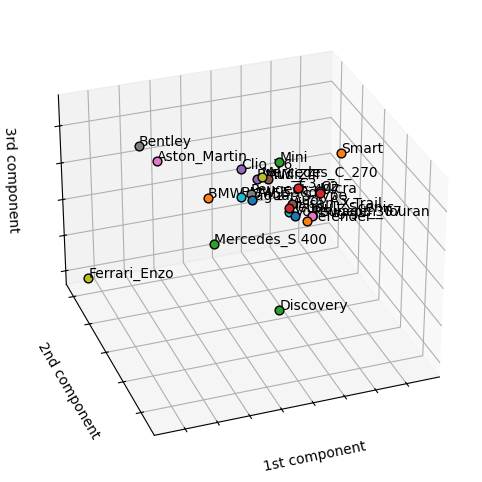

In [31]:
# Plot3D

model.plot3D(cars)

###  <span style="color:red">Outliers in standard PCA </span>

c:\Users\smussa01\Anaconda3\envs\py310\lib\site-packages\threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


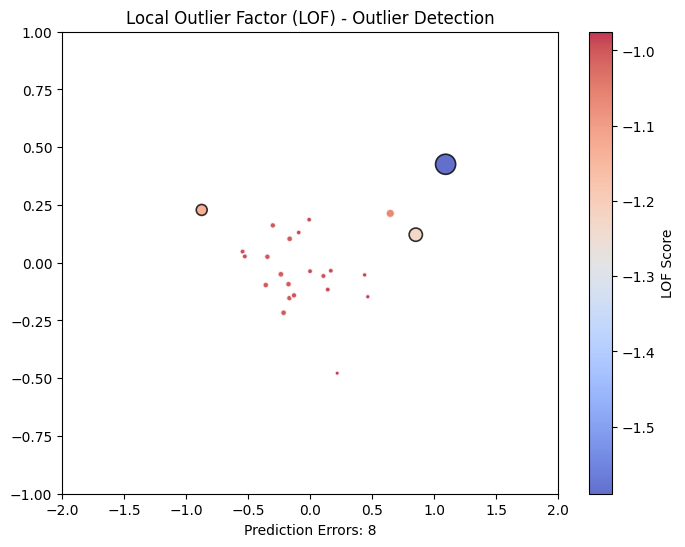

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from matplotlib.legend_handler import HandlerPathCollection

# Assuming X is already defined as 'components_copy'
#X = comp_var  # Keep the original data
X = components_copy 
n_outliers = 5

# Define ground truth for comparison
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1  # Mark last `n_outliers` as outliers

# Apply Local Outlier Factor
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = clf.fit_predict(X)
n_errors = (y_pred != ground_truth).sum()
X_scores = clf.negative_outlier_factor_

# Normalize the scores for visualization
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

# Assign colors: Inliers vs Outliers
colors = np.where(y_pred == -1, "red", "blue")  # Outliers in red, inliers in blue

# Create scatter plot with color mapping
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X[:, 0],
    X[:, 1],
    c=X_scores,  # Use LOF scores for color intensity
    cmap="coolwarm",  # Colormap for better visuals
    s=200 * radius + 10,  # Adjust marker size dynamically
    edgecolors=np.where(y_pred == -1, "black", "white"),  # Outliers get black edge
    linewidth=1.2,
    alpha=0.8,  # Add some transparency
)

# Customize axis & labels
plt.axis("tight")
plt.xlim((-2, 2))
plt.ylim((-1, 1))
plt.xlabel(f"Prediction Errors: {n_errors}")
plt.title("Local Outlier Factor (LOF) - Outlier Detection")

# Add colorbar for outlier scores
cbar = plt.colorbar(scatter)
cbar.set_label("LOF Score")

# Add legend
plt.scatter([], [], c="blue", s=100, label="Inliers")  #
plt.show()


###  <span style="color:red">MNIST dataset </span>

In [33]:
import torchvision
import torch
import torchvision.datasets as datasets
from torchvision.transforms import ToTensor

mnist_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=None)
x_train=mnist_trainset.data.type(torch.DoubleTensor)/255

mnist_testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=None)
x_test=mnist_testset.data.type(torch.DoubleTensor)/255

x_train = torch.reshape(x_train, (x_train.shape[0], 784))
x_test = torch.reshape(x_test, (x_test.shape[0], 784))


In [34]:
# First model
nb_comp = 7
alpha = 2
model = GiniPca(gini_param=alpha, n_components=nb_comp)
F = model.fit_inverse(x_train, x_test)
F = torch.reshape(F, (x_test.shape[0], 28, 28))

c:\Users\smussa01\Documents\Python Scripts\Book Gini\ACP\Gini_PCA.py:71: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Copy.cpp:305.)
  vecp = vecp.type(torch.float64)


In [35]:
# Second model
alpha1 = 3
model = GiniPca(gini_param=alpha1, n_components=nb_comp)
F1 = model.fit_inverse(x_train, x_test)
F1 = torch.reshape(F1, (x_test.shape[0], 28, 28))

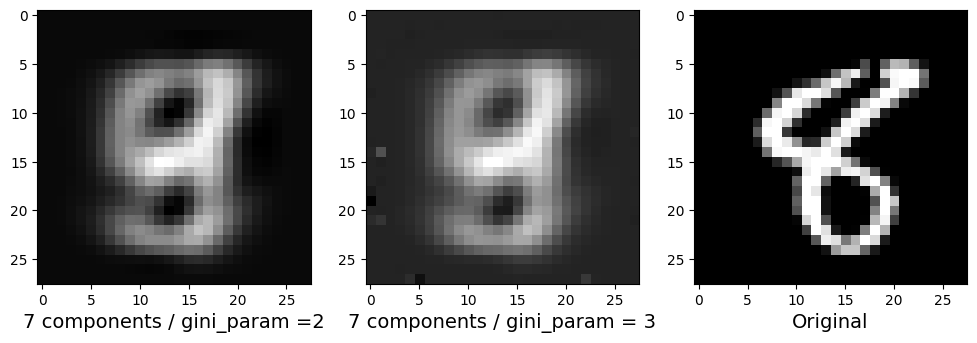

In [36]:
plt.figure(figsize=(12,8))
chiffre = 84
# Model 1
plt.subplot(1, 3, 1)
plt.imshow(F.numpy()[chiffre],
              cmap = plt.cm.gray)
plt.xlabel(f"{nb_comp} components / gini_param ={alpha}", fontsize = 14)
# Model 2
plt.subplot(1, 3, 2)
plt.imshow(F1.numpy()[chiffre],
              cmap = plt.cm.gray)
plt.xlabel(f"{nb_comp} components / gini_param = {alpha1}", fontsize = 14)
# Original
xx = torch.reshape(x_test, (10000, 28, 28))
plt.subplot(1, 3, 3)
plt.imshow(xx[chiffre], cmap=plt.cm.gray)
plt.xlabel("Original", fontsize = 14)
plt.show()


###  <span style="color:red">Fashion MNIST dataset </span>

In [37]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.5,), (0.5,))  
    ])

# Load
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                              download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                             download=True, transform=transform)
x_train = train_set.data.unsqueeze(1).float()
x_test = test_set.data.unsqueeze(1).float()
x_train = torch.reshape(x_train, (x_train.shape[0], 784))
x_test = torch.reshape(x_test, (x_test.shape[0], 784))

In [38]:
# Add noise in testing images
# Add Gaussian noise to the test set
noise = torch.randn(x_test.shape) * 0.3
x_test_noisy = x_test + noise
x_test_noisy = torch.clamp(x_test_noisy, 0, 1)
# Original image
plt.subplot(1, 2, 1)
xx = torch.reshape(x_test, (10000, 28, 28))
plt.imshow(xx[1], cmap=plt.cm.gray)
plt.xlabel("Original", fontsize = 14)
# Original
plt.subplot(1, 2, 2)
xx_noisy = torch.reshape(x_test_noisy, (10000, 28, 28))
plt.imshow(xx_noisy[1], cmap=plt.cm.gray)
plt.xlabel("Noisy", fontsize = 14)

Text(0.5, 0, 'Noisy')

In [39]:
# First model
nb_comp = 5
alpha = 2
model = GiniPca(gini_param=alpha, n_components=nb_comp)
F = model.fit_inverse(x_train, x_test_noisy)
F = torch.reshape(F, (x_test.shape[0], 28, 28))
# Second model
alpha1 = 3
model = GiniPca(gini_param=alpha1, n_components=nb_comp)
F1 = model.fit_inverse(x_train, x_test_noisy)
F1 = torch.reshape(F1, (x_test.shape[0], 28, 28))

In [40]:
plt.figure(figsize=(12,8))
chiffre = 1

plt.subplot(1, 3, 1)
plt.imshow(F.numpy()[chiffre],
              cmap = plt.cm.gray)
plt.xlabel(f"{nb_comp} components / gini_param ={alpha}", fontsize = 14)

# alpha = alpha1
plt.subplot(1, 3, 2)
plt.imshow(F1.numpy()[chiffre],
              cmap = plt.cm.gray)
plt.xlabel(f"{nb_comp} components / gini_param = {alpha1}", fontsize = 14)

# Originale
xx = torch.reshape(x_test_noisy, (10000, 28, 28))
plt.subplot(1, 3, 3)
plt.imshow(xx[chiffre], cmap=plt.cm.gray)
plt.xlabel("Original", fontsize = 14)


Text(0.5, 0, 'Original')

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca.fit(x_train)
compress_images = pca.transform(x_test_noisy)
reconstruct_images = pca.inverse_transform(compress_images)
reconstruct_images.shape

(10000, 784)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Labels
train_labels = [label for _, label in train_set]
test_labels = [label for _, label in test_set]
# Instantation
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
# Fit the model on the training data
clf.fit(x_train, train_labels)


In [ ]:
# Predict
test_pred_pca = clf.predict(reconstruct_images)
accuracy_pca = accuracy_score(test_labels, test_pred_pca)

# Predict with Gini PCA
accuracy_gini = []
nu_values = []
for nu in np.arange(1, 4.5, 0.5):
    model = GiniPca(gini_param=nu, n_components=nb_comp)
    reconstruct_images = model.fit_inverse(x_train, x_test_noisy)
    y_pred = clf.predict(reconstruct_images)
    accuracy_gini.append(accuracy_score(test_labels, y_pred))
    nu_values.append(nu)



In [ ]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(nu_values, accuracy_gini, marker='o', linestyle='-', color='b', label = 'Accuracy Gini')
plt.scatter(1, accuracy_pca, color='r', label='Accuracy PCA', zorder=5) 
plt.title('Accuracy of random forest on compressed images')
plt.xlabel('nu values')
plt.ylabel('Accuracy')
plt.legend()
plt.show()